In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import re
import string        

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression


In [ ]:
data = pd.read_csv(r"C:\Users\ASUS\Downloads\NLP PROJECT\final_dataset.csv")
data_Target = data.copy()
data.head()


,URL,MobileURL,Date,Title,Title_English,source_domain,financial_source,financial_source_clean
0,https://www.moneycontrol.com/news/business/mar...,https://www.moneycontrol.com/news/business/mar...,2025-11-03 08:30:00,India pandemic - era valuation premium over EM...,India pandemic - era valuation premium over EM...,moneycontrol.com,moneycontrol,Moneycontrol
1,https://www.financialexpress.com/policy/econom...,https://www.financialexpress.com/policy/econom...,2025-11-04 11:45:00,November Economic Watchlist : 4 key data point...,November Economic Watchlist : 4 key data point...,financialexpress.com,financialexpress,Financial Express
2,https://www.moneycontrol.com/news/business/mar...,https://www.moneycontrol.com/news/business/mar...,2025-11-04 02:00:00,Daily Voice : Bay Capital Nikunj Doshi sees st...,Daily Voice : Bay Capital Nikunj Doshi sees st...,moneycontrol.com,moneycontrol,Moneycontrol
3,https://www.financialexpress.com/business/indu...,https://www.financialexpress.com/business/indu...,2025-11-03 09:00:00,October Manufacturing output hits 5 - year hig...,October Manufacturing output hits 5 - year hig...,financialexpress.com,financialexpress,Financial Express
4,https://economictimes.indiatimes.com/news/econ...,https://m.economictimes.com/news/economy/indic...,2025-11-03 20:30:00,Manufacturing activity picks up in October on ...,Manufacturing activity picks up in October on ...,economictimes.indiatimes.com,economictimes,Economic Times


In [3]:
data = pd.DataFrame(data.Title_English)

data.head()

,Title_English
0,India pandemic - era valuation premium over EM...
1,November Economic Watchlist : 4 key data point...
2,Daily Voice : Bay Capital Nikunj Doshi sees st...
3,October Manufacturing output hits 5 - year hig...
4,Manufacturing activity picks up in October on ...


# Data Cleaning or Pre-Processing

# Step 1 :- Lower case

In [4]:
data.Title_English = data.Title_English.str.lower()

In [5]:
data.iloc[1500,0]

'indian shares set to open higher on hopes for renewed us - iran talks'

# Removing Stop Words

In [9]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('English')

print("No.of StopWords :",len(stop))
stop

No.of StopWords : 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [10]:
data.iloc[1500,0]

'indian shares set to open higher on hopes for renewed us - iran talks'

# Remove url

In [11]:
data['Title_English'] = data['Title_English'].replace(r'http\S+|www\S+', '', regex=True)
data.iloc[1,0]

'november economic watchlist : 4 key data points set to reveal growth and inflation trends'

# Step 2 :- Punctuation

In [12]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [13]:
def remove_punctuation(text):
    text_nopunt="".join([c for c in text if c not in string.punctuation])
    return text_nopunt

In [14]:
data.iloc[1500,0]

'indian shares set to open higher on hopes for renewed us - iran talks'

In [15]:
data['Title_English'] = data['Title_English'].apply(lambda x : remove_punctuation(x))

In [16]:
data.iloc[1500,0]

'indian shares set to open higher on hopes for renewed us  iran talks'

# Remove Number

In [17]:
data['Title_English'] = data['Title_English'].replace(r'\d+', '', regex=True)

In [18]:
data.iloc[57,0]

'retail inflation likely to hit record low of     in october on falling food prices  base effect and gst cuts  mint poll'

# Common Words

In [19]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
print(len(stop_words))   # should be ~198
print(list(stop_words)[:10])

198
['no', 'shouldn', 'then', 'who', "shan't", 'd', 'its', 'having', 'can', 'doing']


In [21]:
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in stop_words])

data['Title_English'] = data['Title_English'].apply(remove_stopwords)

In [22]:
print(data.iloc[57, 0])

retail inflation likely hit record low october falling food prices base effect gst cuts mint poll


# Lemmatization

In [23]:
from nltk.stem import WordNetLemmatizer 
import nltk
nltk.download('wordnet')
# Init the Wordnet Lemmatizer
lemmatizer = WordNetLemmatizer()
w_tokenizer = nltk.tokenize.WhitespaceTokenizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [24]:
def lemmatize_text(Title_English):
    return [lemmatizer.lemmatize(w,"v") for w in w_tokenizer.tokenize(Title_English)]

In [25]:
data['Title_English'] = data.Title_English.apply(lambda x :' '.join(lemmatize_text(x)))
data.iloc[57,0]

'retail inflation likely hit record low october fall food price base effect gst cut mint poll'

# Strip extra whitespace

In [26]:
data.iloc[1500,0]

'indian share set open higher hop renew us iran talk'

In [27]:
data['Title_English'] = (data['Title_English'].astype("str").str.rstrip())
data.iloc[1500,0]

'indian share set open higher hop renew us iran talk'

### Removing Duplicate Row

In [28]:
data = data.drop_duplicates('Title_English') 
data

,Title_English
0,india pandemic era valuation premium em peer f...
1,november economic watchlist key data point set...
2,daily voice bay capital nikunj doshi see stron...
3,october manufacture output hit year high stron...
4,manufacture activity pick october gst relief t...
...,...
1513,market rally continue fundamentals weaken warn...
1514,stock action rise market hope resumption usira...
1515,make drill oil wake
1516,us set fresh condition iran talk strait hormuz...


# Document Term Matrix(DTM)

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english')
data_cv = cv.fit_transform(data.Title_English)
data_dtm = pd.DataFrame(data_cv.toarray(), columns=cv.get_feature_names_out())
tdm = data_dtm.transpose()
tdm

,0,1,2,3,4,5,6,7,8,9,...,1498,1499,1500,1501,1502,1503,1504,1505,1506,1507
aadhaar,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aayog,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abakkus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abandon,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abb,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
कल,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
चढ,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
पय,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
बन,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
tdm['freq'] = tdm.sum(axis=1)
tdm.reset_index(inplace=True)
tdm

,index,0,1,2,3,4,5,6,7,8,...,1499,1500,1501,1502,1503,1504,1505,1506,1507,freq
0,aadhaar,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,aayog,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
2,abakkus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,abandon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,abb,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3060,कल,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3061,चढ,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3062,पय,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3063,बन,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [31]:
tdm1 = tdm[["index","freq"]] #SUBSET OF 2 COLUMNS
tdm1.rename(columns = {'index':'Word'}, inplace = True) # RENAMING
tdm1.sort_values(by='freq',ascending=False,inplace=True) # SORTING DATA
tdm1.head(10)

,Word,freq
1326,india,359
1616,market,326
2610,stock,205
2057,price,189
1790,nifty,148
1840,oil,145
2958,war,141
1130,gold,140
1389,iran,138
1165,growth,133


# Word Cloud`

In [32]:
text = " ".join(review for review in data.Title_English)
print ("There are {} words in the combination of all review.".format(len(text)))

There are 105310 words in the combination of all review.


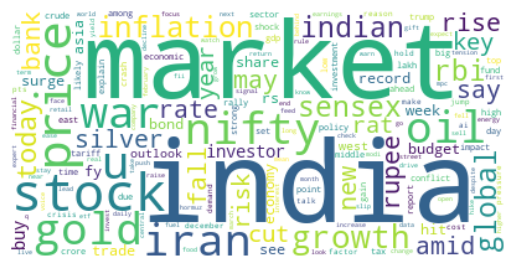

In [33]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

cloud = WordCloud(stopwords=set(STOPWORDS), # BACK UP
                      background_color="white",
                      collocations=False,
                      max_words=200).generate(text)

plt.imshow(cloud, interpolation='bilinear') # IM = IMAGE
plt.axis("off") # NO AXIS
plt.show() # DISPLAY PLOT

# Sentiment Analysis

In [34]:
data.head()

,Title_English
0,india pandemic era valuation premium em peer f...
1,november economic watchlist key data point set...
2,daily voice bay capital nikunj doshi see stron...
3,october manufacture output hit year high stron...
4,manufacture activity pick october gst relief t...


In [35]:
from textblob import TextBlob

data['polarity'] = data['Title_English'].apply(lambda x: TextBlob(x).sentiment.polarity) # polarity range -1 to +1
data.head(5)

,Title_English,polarity
0,india pandemic era valuation premium em peer f...,0.175000
1,november economic watchlist key data point set...,0.100000
2,daily voice bay capital nikunj doshi see stron...,0.096667
3,october manufacture output hit year high stron...,0.197778
4,manufacture activity pick october gst relief t...,0.000000


In [36]:
data['Sentiment'] = np.where(data['polarity']>= 0, 'Positive', 'Negative')
data.head()

,Title_English,polarity,Sentiment
0,india pandemic era valuation premium em peer f...,0.175000,Positive
1,november economic watchlist key data point set...,0.100000,Positive
2,daily voice bay capital nikunj doshi see stron...,0.096667,Positive
3,october manufacture output hit year high stron...,0.197778,Positive
4,manufacture activity pick october gst relief t...,0.000000,Positive


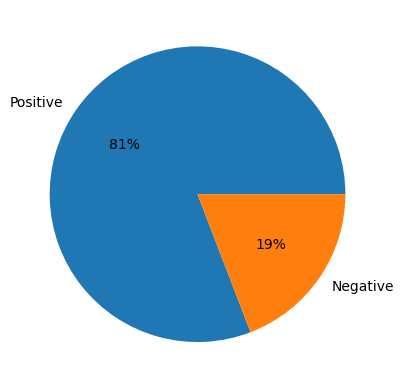

In [37]:
data.Sentiment.value_counts().plot.pie(autopct="%0.0f%%");
plt.show()

# TF-IDF

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

# initialize
tfidf = TfidfVectorizer(stop_words='english')

# fit and transform your cleaned column
X = tfidf.fit_transform(data['Title_English'])

# check shape
print(X.shape)

# feature names
print(tfidf.get_feature_names_out()[:20])

(1508, 3065)
['aadhaar' 'aayog' 'abakkus' 'abandon' 'abb' 'able' 'abound' 'abroad'
 'accelerate' 'acceleration' 'access' 'accessibility' 'accessible'
 'accord' 'account' 'accumulate' 'achieve' 'achr' 'acquire' 'act']


In [39]:
# =========================
# IMPORTS
# =========================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================
# TF-IDF VECTORIZER
# =========================
tfidf_vectorizer = TfidfVectorizer(
    use_idf=True,
    stop_words='english',
    analyzer='word'
)

# =========================
# FIT & TRANSFORM
# =========================
tfidf_vectors = tfidf_vectorizer.fit_transform(data['Title_English'])

# feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# =========================
# CONVERT TO DATAFRAME
# =========================
df_tfidf = pd.DataFrame(
    tfidf_vectors.toarray(),
    columns=feature_names
)

print(df_tfidf.head())

   aadhaar  aayog  abakkus  abandon  abb  able  abound  abroad  accelerate  \
0      0.0    0.0      0.0      0.0  0.0   0.0     0.0     0.0         0.0   
1      0.0    0.0      0.0      0.0  0.0   0.0     0.0     0.0         0.0   
2      0.0    0.0      0.0      0.0  0.0   0.0     0.0     0.0         0.0   
3      0.0    0.0      0.0      0.0  0.0   0.0     0.0     0.0         0.0   
4      0.0    0.0      0.0      0.0  0.0   0.0     0.0     0.0         0.0   

   acceleration  ...  zone  zubarevich   आग   उत   उम   कल   चढ   पय   बन  रहन  
0           0.0  ...   0.0         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1           0.0  ...   0.0         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2           0.0  ...   0.0         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3           0.0  ...   0.0         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4           0.0  ...   0.0         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 3065 columns]


In [40]:
# get highest TF-IDF word for each row
df_tfidf['Top_Word'] = df_tfidf.idxmax(axis=1)

# check result
print(df_tfidf[['Top_Word']].head())

    Top_Word
0   pandemic
1  watchlist
2        qcy
3     output
4   activity


# Machine Learning Model 

In [41]:
data.Sentiment

0       Positive
1       Positive
2       Positive
3       Positive
4       Positive
          ...   
1513    Positive
1514    Positive
1515    Positive
1516    Positive
1517    Positive
Name: Sentiment, Length: 1508, dtype: str

In [42]:
print(data.columns)

Index(['Title_English', 'polarity', 'Sentiment'], dtype='str')


In [43]:
print(data_Target.columns)

Index(['URL', 'MobileURL', 'Date', 'Title', 'Title_English', 'source_domain',
       'financial_source', 'financial_source_clean'],
      dtype='str')


In [44]:
data_dtm['Sentiment'] = data['Sentiment']
data_dtm.head()

,aadhaar,aayog,abakkus,abandon,abb,able,abound,abroad,accelerate,acceleration,...,zubarevich,आग,उत,उम,कल,चढ,पय,बन,रहन,Sentiment
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Positive
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Positive
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Positive
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Positive
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Positive


### Data Partition

In [45]:
from sklearn.model_selection import train_test_split

# remove missing values
data_dtm = data_dtm.dropna()

# features and target
X = data_dtm.drop('Sentiment', axis=1)
y = data_dtm['Sentiment']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train:\n", y_train.value_counts())
print("\nTest:\n", y_test.value_counts())

Train:
 Sentiment
Positive    847
Negative    202
Name: count, dtype: int64

Test:
 Sentiment
Positive    364
Negative     86
Name: count, dtype: int64


### Model Building 

In [69]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Prediction on Train Data

In [70]:
# prediction on train data
y_train_pred = model.predict(X_train)

# evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

Train Accuracy: 0.9075309818875119
              precision    recall  f1-score   support

    Negative       0.97      0.53      0.69       202
    Positive       0.90      1.00      0.95       847

    accuracy                           0.91      1049
   macro avg       0.94      0.77      0.82      1049
weighted avg       0.91      0.91      0.90      1049



## Prediction on Test Data

In [71]:
# prediction on test data
y_test_pred = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.7466666666666667
              precision    recall  f1-score   support

    Negative       0.27      0.19      0.22        86
    Positive       0.82      0.88      0.85       364

    accuracy                           0.75       450
   macro avg       0.54      0.53      0.53       450
weighted avg       0.71      0.75      0.73       450

